# Reproducing NSGA-II: A Fast and Elitist\\Multiobjective Genetic Algorithm

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math
import time
from copy import deepcopy

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.linewidth": 0.8,
    "figure.dpi": 120,
})

---
## Individual Representation

Each individual in the population carries:
- **`x`** — decision variable vector (the actual solution)
- **`objectives`** — list of objective function values [f1, f2]
- **`rank`** — non-domination rank (1 = best front)
- **`distance`** — crowding distance (higher = more isolated = preferred)

In [ ]:
class Individual:
    def __init__(self, x):
        self.x = np.array(x, dtype=float)
        self.objectives = []
        self.rank = None
        self.distance = 0.0

    def __repr__(self):
        return (f"Individual(rank={self.rank}, dist={self.distance:.3f}, "
                f"obj={[round(o, 4) for o in self.objectives]})")

---
## Fast Non-Dominated Sorting


Sorts the population into fronts F1, F2, ... in O(MN²) time:
- **F1** = solutions not dominated by anyone (the Pareto front)
- **F2** = solutions dominated only by F1 members, etc.

For each individual *p*, we track:
- **S_p**: set of individuals that *p* dominates
- **n_p**: count of individuals that dominate *p*

All individuals with n_p = 0 form F1. Then we peel fronts layer by layer.

In [ ]:
def dominates(p, q):
    """p dominates q if p is no worse on ALL objectives and strictly better on at least one."""
    at_least_one_better = False
    for p_obj, q_obj in zip(p.objectives, q.objectives):
        if p_obj > q_obj:
            return False
        if p_obj < q_obj:
            at_least_one_better = True
    return at_least_one_better


def fast_nondominated_sort(population):
    """Sort population into non-dominated fronts F1, F2, ... (1-indexed ranks)."""
    n = len(population)
    dominated_by_p = [[] for _ in range(n)]  # S_p
    domination_count = [0] * n                # n_p
    fronts = [[]]

    for i, p in enumerate(population):
        for j, q in enumerate(population):
            if i == j:
                continue
            if dominates(p, q):
                dominated_by_p[i].append(j)
            elif dominates(q, p):
                domination_count[i] += 1
        if domination_count[i] == 0:
            p.rank = 1
            fronts[0].append(i)

    current_front = 0
    while fronts[current_front]:
        next_front = []
        for i in fronts[current_front]:
            for j in dominated_by_p[i]:
                domination_count[j] -= 1
                if domination_count[j] == 0:
                    population[j].rank = current_front + 2
                    next_front.append(j)
        current_front += 1
        fronts.append(next_front)

    fronts = [f for f in fronts if f]
    return [[population[i] for i in front] for front in fronts]

---
## Crowding Distance & Crowded Comparison


**Crowding distance** measures how isolated a solution is within its front. For each objective, solutions are sorted and the distance is the normalized gap between neighbors. Boundary solutions get ∞ distance (always preserved).

**Crowded comparison operator (≺_n):** prefer lower rank; if tied, prefer larger crowding distance (less crowded region).

In [ ]:
def crowding_distance_assignment(front):
    """Assign crowding distance to every individual in a single front."""
    n = len(front)
    if n == 0:
        return
    for ind in front:
        ind.distance = 0.0

    num_objectives = len(front[0].objectives)
    for m in range(num_objectives):
        front.sort(key=lambda ind: ind.objectives[m])
        f_min = front[0].objectives[m]
        f_max = front[-1].objectives[m]
        front[0].distance = math.inf
        front[-1].distance = math.inf
        if f_max == f_min:
            continue
        for i in range(1, n - 1):
            front[i].distance += (
                (front[i + 1].objectives[m] - front[i - 1].objectives[m])
                / (f_max - f_min)
            )


def crowded_comparison(ind_a, ind_b):
    """Crowded comparison operator: lower rank wins; ties broken by larger distance."""
    if ind_a.rank < ind_b.rank:
        return ind_a
    if ind_b.rank < ind_a.rank:
        return ind_b
    return ind_a if ind_a.distance > ind_b.distance else ind_b

---
## Genetic Operators

Three operators, exactly as specified in the paper:

1. **Binary Tournament Selection** — pick 2 random individuals, return the winner by crowded comparison
2. **Simulated Binary Crossover (SBX)** — with distribution index η_c = 20 and crossover probability p_c = 0.9
3. **Polynomial Mutation** — with distribution index η_m = 20 and mutation probability p_m = 1/n per variable

In [ ]:
def tournament_selection(population):
    """Binary tournament: pick 2 at random, return crowded-comparison winner."""
    idx_a, idx_b = np.random.choice(len(population), size=2, replace=False)
    return crowded_comparison(population[idx_a], population[idx_b])


def sbx_crossover(parent1, parent2, eta_c, bounds, p_c=0.9):
    """Simulated Binary Crossover Returns two children."""
    n = len(parent1.x)
    child1_x = parent1.x.copy()
    child2_x = parent2.x.copy()

    if np.random.random() > p_c:
        return Individual(child1_x), Individual(child2_x)

    for i in range(n):
        lb, ub = bounds[i]
        if abs(parent1.x[i] - parent2.x[i]) < 1e-10:
            continue

        y1 = min(parent1.x[i], parent2.x[i])
        y2 = max(parent1.x[i], parent2.x[i])

        # Lower child
        u = np.random.random()
        beta = 1.0 + (2.0 * (y1 - lb) / (y2 - y1))
        alpha = 2.0 - beta ** (-(eta_c + 1.0))
        if u <= 1.0 / alpha:
            beta_q = (u * alpha) ** (1.0 / (eta_c + 1.0))
        else:
            beta_q = (1.0 / (2.0 - u * alpha)) ** (1.0 / (eta_c + 1.0))
        c1 = 0.5 * ((y1 + y2) - beta_q * (y2 - y1))

        # Upper child
        u = np.random.random()
        beta = 1.0 + (2.0 * (ub - y2) / (y2 - y1))
        alpha = 2.0 - beta ** (-(eta_c + 1.0))
        if u <= 1.0 / alpha:
            beta_q = (u * alpha) ** (1.0 / (eta_c + 1.0))
        else:
            beta_q = (1.0 / (2.0 - u * alpha)) ** (1.0 / (eta_c + 1.0))
        c2 = 0.5 * ((y1 + y2) + beta_q * (y2 - y1))

        c1 = float(np.clip(c1, lb, ub))
        c2 = float(np.clip(c2, lb, ub))

        if np.random.random() <= 0.5:
            child1_x[i], child2_x[i] = c1, c2
        else:
            child1_x[i], child2_x[i] = c2, c1

    return Individual(child1_x), Individual(child2_x)


def polynomial_mutation(individual, eta_m, bounds):
    """Polynomial mutation Mutates in place."""
    n = len(individual.x)
    p_m = 1.0 / n

    for i in range(n):
        if np.random.random() > p_m:
            continue
        lb, ub = bounds[i]
        y = individual.x[i]
        delta = ub - lb
        u = np.random.random()
        if u < 0.5:
            delta_q = (2.0 * u + (1.0 - 2.0 * u) *
                       (1.0 - (y - lb) / delta) ** (eta_m + 1.0)
                       ) ** (1.0 / (eta_m + 1.0)) - 1.0
        else:
            delta_q = 1.0 - (2.0 * (1.0 - u) + 2.0 * (u - 0.5) *
                             (1.0 - (ub - y) / delta) ** (eta_m + 1.0)
                             ) ** (1.0 / (eta_m + 1.0))
        individual.x[i] = float(np.clip(y + delta_q * delta, lb, ub))

    return individual

---
## NSGA-II Main Algorithm

The core loop:

1. **Combine** parent P_t and offspring Q_t into R_t (size 2N)
2. **Sort** R_t into non-dominated fronts F1, F2, ...
3. **Fill** next generation P_{t+1} front-by-front
4. If the last accepted front overflows, **sort by crowding distance** and take the most isolated
5. **Generate** new offspring Q_{t+1} via selection + crossover + mutation

In [ ]:
def initialize_population(N, n_vars, bounds):
    """Create N individuals with uniformly random decision variables."""
    return [Individual([np.random.uniform(lb, ub) for lb, ub in bounds]) for _ in range(N)]


def evaluate_population(population, problem_fn):
    """Evaluate objective values for every individual."""
    for ind in population:
        ind.objectives = problem_fn(ind.x)


def make_new_population(population, bounds, eta_c=20, eta_m=20):
    """Generate N offspring via tournament selection + SBX + polynomial mutation."""
    N = len(population)
    offspring = []
    while len(offspring) < N:
        p1 = tournament_selection(population)
        p2 = tournament_selection(population)
        c1, c2 = sbx_crossover(p1, p2, eta_c, bounds)
        polynomial_mutation(c1, eta_m, bounds)
        polynomial_mutation(c2, eta_m, bounds)
        offspring.append(c1)
        if len(offspring) < N:
            offspring.append(c2)
    return offspring


def nsga2_step(parents, offspring, N):
    """One generation: combine 2N, sort, select best N by rank + crowding."""
    combined = parents + offspring
    fronts = fast_nondominated_sort(combined)
    next_pop = []
    for front in fronts:
        crowding_distance_assignment(front)
        if len(next_pop) + len(front) <= N:
            next_pop.extend(front)
        else:
            front.sort(key=lambda ind: ind.distance, reverse=True)
            next_pop.extend(front[:N - len(next_pop)])
            break
    return next_pop


def run_nsga2(problem_fn, N, n_vars, bounds, n_generations,
              eta_c=20, eta_m=20, seed=None):
    """Run the full NSGA-II algorithm. Returns (final_population, history)."""
    if seed is not None:
        np.random.seed(seed)

    population = initialize_population(N, n_vars, bounds)
    evaluate_population(population, problem_fn)
    fronts = fast_nondominated_sort(population)
    for front in fronts:
        crowding_distance_assignment(front)

    history = []
    for gen in range(n_generations):
        offspring = make_new_population(population, bounds, eta_c, eta_m)
        evaluate_population(offspring, problem_fn)
        population = nsga2_step(population, offspring, N)
        best_f1 = min(ind.objectives[0] for ind in population)
        history.append(best_f1)
        if (gen + 1) % 50 == 0:
            print(f"  Gen {gen+1}/{n_generations} — best f1: {best_f1:.6f}")

    return population, history

---
## ZDT Benchmark Problems


| Problem | Variables | Pareto Front Shape |
|---------|-----------|-------------------|
| ZDT1 | 30, all in [0,1] | Convex |
| ZDT2 | 30, all in [0,1] | Non-convex
| ZDT3 | 30, all in [0,1] | Disconnected (5 segments)
| ZDT4 | 10, x₁∈[0,1], rest∈[-5,5] | Convex (with local fronts)

In [ ]:
# ---- ZDT1: Convex front ----
def zdt1(x):
    f1 = x[0]
    g = 1.0 + 9.0 * np.sum(x[1:]) / (len(x) - 1)
    f2 = g * (1.0 - np.sqrt(f1 / g))
    return [f1, f2]

def zdt1_bounds(n=30): return [(0.0, 1.0)] * n
def zdt1_front(n_points=500):
    f1 = np.linspace(0, 1, n_points)
    return f1, 1.0 - np.sqrt(f1)

# ---- ZDT2: Non-convex front ----
def zdt2(x):
    f1 = x[0]
    g = 1.0 + 9.0 * np.sum(x[1:]) / (len(x) - 1)
    f2 = g * (1.0 - (f1 / g) ** 2)
    return [f1, f2]

def zdt2_bounds(n=30): return [(0.0, 1.0)] * n
def zdt2_front(n_points=500):
    f1 = np.linspace(0, 1, n_points)
    return f1, 1.0 - f1 ** 2

# ---- ZDT3: Disconnected front ----
def zdt3(x):
    f1 = x[0]
    g = 1.0 + 9.0 * np.sum(x[1:]) / (len(x) - 1)
    f2 = g * (1.0 - np.sqrt(f1 / g) - (f1 / g) * np.sin(10.0 * np.pi * f1))
    return [f1, f2]

def zdt3_bounds(n=30): return [(0.0, 1.0)] * n
def zdt3_front(n_points=1000):
    f1 = np.linspace(0, 1, n_points)
    f2 = 1.0 - np.sqrt(f1) - f1 * np.sin(10.0 * np.pi * f1)
    # Keep only non-dominated points
    pf1, pf2 = [], []
    for i in range(len(f1)):
        dominated = False
        for j in range(len(f1)):
            if i != j and f1[j] <= f1[i] and f2[j] <= f2[i] and (f1[j] < f1[i] or f2[j] < f2[i]):
                dominated = True
                break
        if not dominated:
            pf1.append(f1[i]); pf2.append(f2[i])
    return np.array(pf1), np.array(pf2)

# ---- ZDT4: Many local fronts ----
def zdt4(x):
    f1 = x[0]
    g = 1.0 + 10.0 * (len(x) - 1) + np.sum(x[1:]**2 - 10.0 * np.cos(4.0 * np.pi * x[1:]))
    f2 = g * (1.0 - np.sqrt(f1 / g))
    return [f1, f2]

def zdt4_bounds(n=10):
    return [(0.0, 1.0)] + [(-5.0, 5.0)] * (n - 1)
def zdt4_front(n_points=500):
    f1 = np.linspace(0, 1, n_points)
    return f1, 1.0 - np.sqrt(f1)

# ---- Problems ----
PROBLEMS = {
    "ZDT1": {"fn": zdt1, "bounds": zdt1_bounds, "front": zdt1_front, "n_vars": 30},
    "ZDT2": {"fn": zdt2, "bounds": zdt2_bounds, "front": zdt2_front, "n_vars": 30},
    "ZDT3": {"fn": zdt3, "bounds": zdt3_bounds, "front": zdt3_front, "n_vars": 30},
    "ZDT4": {"fn": zdt4, "bounds": zdt4_bounds, "front": zdt4_front, "n_vars": 10},
}

---
## Performance Metrics

Metrics from the paper:

**Convergence metric Υ (Upsilon):** Average minimum Euclidean distance from each obtained solution to the nearest point on the true Pareto front. *Lower = better; 0 = perfect convergence.*

**Diversity metric Δ (Delta):** Measures how uniformly the obtained solutions are spread. Uses Equation (1) from the paper. *Lower = better; 0 = perfectly uniform spread.*

In [ ]:
def convergence_metric(obtained_f1, obtained_f2, true_f1, true_f2):
    """Average min Euclidean distance from obtained solutions to true front."""
    obtained = np.column_stack([obtained_f1, obtained_f2])
    reference = np.column_stack([true_f1, true_f2])
    min_dists = []
    for sol in obtained:
        dists = np.sqrt(np.sum((reference - sol) ** 2, axis=1))
        min_dists.append(np.min(dists))
    return float(np.mean(min_dists))


def diversity_metric(obtained_f1, obtained_f2, true_f1, true_f2):
    """Non-uniformity measure Δ from Eq. (1) of the paper."""
    order = np.argsort(obtained_f1)
    f1 = np.array(obtained_f1)[order]
    f2 = np.array(obtained_f2)[order]
    N = len(f1)
    if N < 2:
        return float('inf')

    d = np.sqrt(np.diff(f1)**2 + np.diff(f2)**2)
    d_mean = np.mean(d)

    # Boundary distances to extreme points on true front
    d_f = float(np.sqrt((f1[0] - true_f1[0])**2 + (f2[0] - true_f2[0])**2))
    d_l = float(np.sqrt((f1[-1] - true_f1[-1])**2 + (f2[-1] - true_f2[-1])**2))

    numerator = d_f + d_l + np.sum(np.abs(d - d_mean))
    denominator = d_f + d_l + (N - 1) * d_mean
    return 0.0 if denominator == 0 else float(numerator / denominator)

---
## Run NSGA-II on All ZDT Problems

Using the paper's parameters: **N=100, 250 generations, η_c=20, η_m=20**

In [ ]:
# Paper parameters
N_POP = 100
N_GEN = 250
ETA_C = 20
ETA_M = 20
SEED  = 42

results = {}

for name in ["ZDT1", "ZDT2", "ZDT3", "ZDT4"]:
    print(f"\n{'='*50}")
    print(f"  Running NSGA-II on {name}")
    print(f"{'='*50}")

    cfg = PROBLEMS[name]
    bounds = cfg["bounds"](cfg["n_vars"])

    t0 = time.time()
    pop, history = run_nsga2(
        problem_fn=cfg["fn"], N=N_POP, n_vars=cfg["n_vars"],
        bounds=bounds, n_generations=N_GEN,
        eta_c=ETA_C, eta_m=ETA_M, seed=SEED
    )
    elapsed = time.time() - t0

    front1 = [ind for ind in pop if ind.rank == 1]
    f1 = [ind.objectives[0] for ind in front1]
    f2 = [ind.objectives[1] for ind in front1]

    results[name] = {"f1": f1, "f2": f2, "history": history, "front_size": len(front1)}
    print(f"  Done in {elapsed:.1f}s — Front-1 size: {len(front1)}")


  Running NSGA-II on ZDT1
  Gen 50/250 — best f1: 0.000000
  Gen 100/250 — best f1: 0.000000
  Gen 150/250 — best f1: 0.000000
  Gen 200/250 — best f1: 0.000000
  Gen 250/250 — best f1: 0.000000
  Done in 16.7s — Front-1 size: 100

  Running NSGA-II on ZDT2
  Gen 50/250 — best f1: 0.000000
  Gen 100/250 — best f1: 0.000000
  Gen 150/250 — best f1: 0.000000
  Gen 200/250 — best f1: 0.000000
  Gen 250/250 — best f1: 0.000000
  Done in 17.7s — Front-1 size: 100

  Running NSGA-II on ZDT3
  Gen 50/250 — best f1: 0.000000
  Gen 100/250 — best f1: 0.000000
  Gen 150/250 — best f1: 0.000000
  Gen 200/250 — best f1: 0.000000
  Gen 250/250 — best f1: 0.000000
  Done in 17.2s — Front-1 size: 100

  Running NSGA-II on ZDT4
  Gen 50/250 — best f1: 0.000000
  Gen 100/250 — best f1: 0.000000
  Gen 150/250 — best f1: 0.000000
  Gen 200/250 — best f1: 0.000000
  Gen 250/250 — best f1: 0.000000
  Done in 12.4s — Front-1 size: 100


---
## Pareto Front Plots


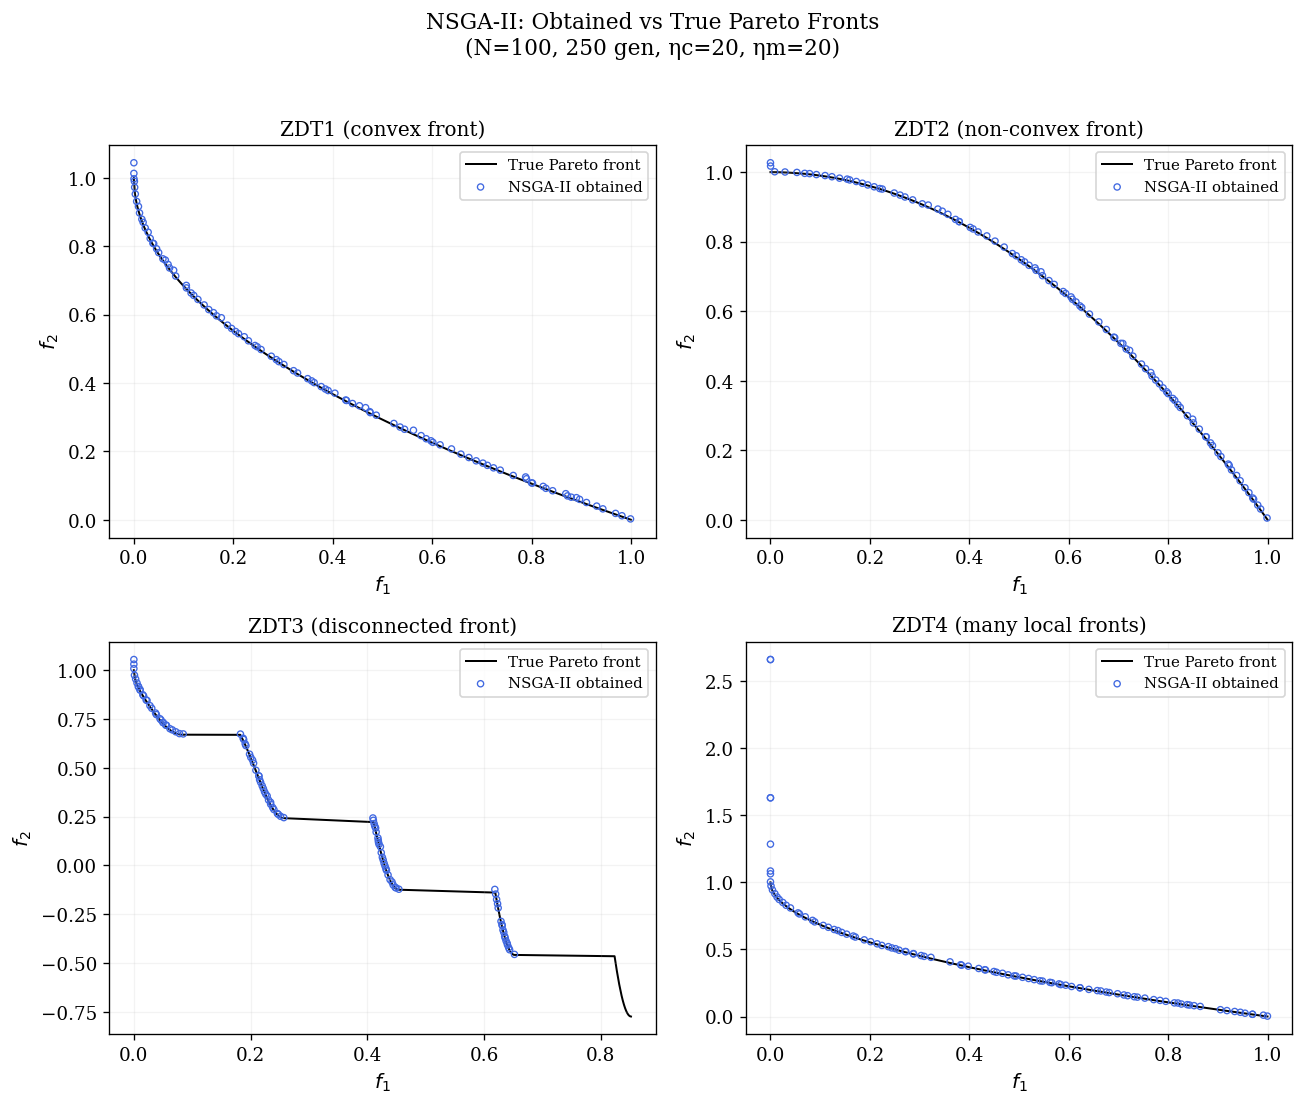

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

titles = [
    "ZDT1 (convex front)",
    "ZDT2 (non-convex front)",
    "ZDT3 (disconnected front)",
    "ZDT4 (many local fronts)",
]

for ax, name, title in zip(axes, ["ZDT1", "ZDT2", "ZDT3", "ZDT4"], titles):
    cfg = PROBLEMS[name]
    true_f1, true_f2 = cfg["front"](n_points=500)

    # True Pareto front
    ax.plot(true_f1, true_f2, "k-", linewidth=1.2, label="True Pareto front", zorder=1)

    # Obtained solutions
    r = results[name]
    order = np.argsort(r["f1"])
    ax.scatter(np.array(r["f1"])[order], np.array(r["f2"])[order],
               s=14, facecolors="none", edgecolors="royalblue",
               linewidths=0.8, zorder=2, label="NSGA-II obtained")

    ax.set_xlabel(r"$f_1$", fontsize=12)
    ax.set_ylabel(r"$f_2$", fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.15)

fig.suptitle("NSGA-II: Obtained vs True Pareto Fronts\n(N=100, 250 gen, ηc=20, ηm=20)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Convergence Curves

Tracking the best (minimum) $f_1$ value across generations for each problem.

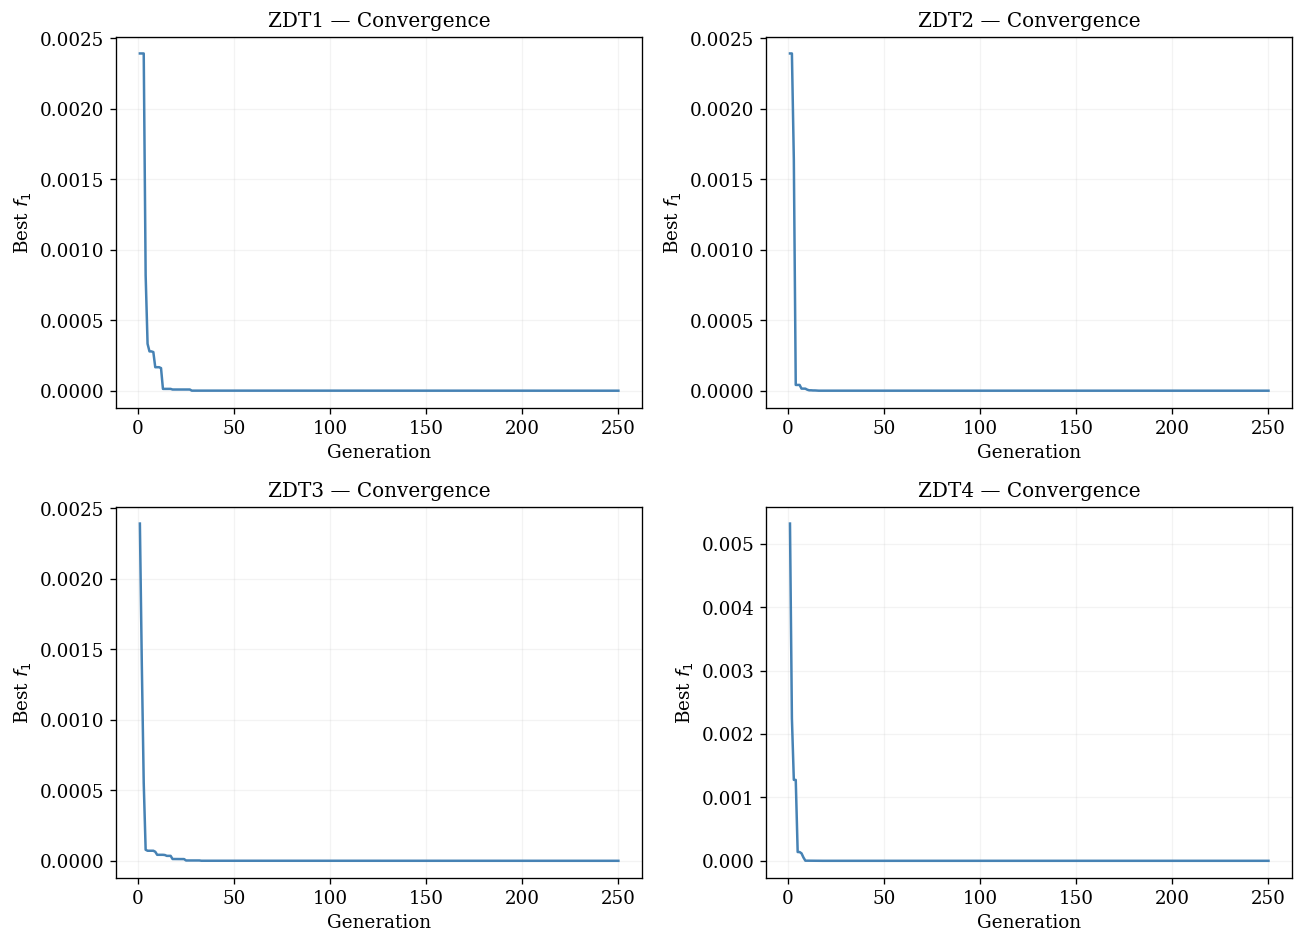

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for ax, name in zip(axes, ["ZDT1", "ZDT2", "ZDT3", "ZDT4"]):
    h = results[name]["history"]
    ax.plot(range(1, len(h) + 1), h, color="steelblue", linewidth=1.5)
    ax.set_xlabel("Generation", fontsize=11)
    ax.set_ylabel("Best $f_1$", fontsize=11)
    ax.set_title(f"{name} — Convergence", fontsize=12)
    ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.show()

---
## Single-Run Performance Metrics

Computing the convergence metric $\Upsilon$ and diversity metric $\Delta$ for the single run above.

In [ ]:
ups_label = "\u03a5 (conv.)"
dlt_label = "\u0394 (div.)"
print(f"{'Problem':<8} {'Front Size':>10} {ups_label:>14} {dlt_label:>14}")
print("-" * 48)

for name in ["ZDT1", "ZDT2", "ZDT3", "ZDT4"]:
    r = results[name]
    cfg = PROBLEMS[name]
    true_f1, true_f2 = cfg["front"](n_points=500)

    ups = convergence_metric(r["f1"], r["f2"], true_f1, true_f2)
    dlt = diversity_metric(r["f1"], r["f2"], true_f1, true_f2)

    print(f"{name:<8} {r['front_size']:>10} {ups:>14.6f} {dlt:>14.6f}")

Problem  Front Size      Υ (conv.)       Δ (div.)
------------------------------------------------
ZDT1            100       0.004227       0.373641
ZDT2            100       0.003016       0.375723
ZDT3            100       0.005359       0.655765
ZDT4            100       0.053513       0.992018


---
## Statistical Validation (10 Independent Trials)

 We now run **10 independent trials per problem** (seeds 100–109) and compute the mean and variance of $\Upsilon$ and $\Delta$.

> **Runtime note:** This cell runs 40 full NSGA-II executions (10 runs × 4 problems).

In [ ]:
# Published values from Tables II and III (real-coded NSGA-II with real parameters)
# Each tuple: (mean_upsilon, var_upsilon, mean_delta, var_delta)
PAPER_VALUES = {
    "ZDT1": (0.033482, 0.004750, 0.390307, 0.001876),
    "ZDT2": (0.072391, 0.031689, 0.430776, 0.004721),
    "ZDT3": (0.114500, 0.007940, 0.738540, 0.019706),
    "ZDT4": (0.513053, 0.118460, 0.702612, 0.064648),
}

N_RUNS = 10
trial_results = {}

for name in ["ZDT1", "ZDT2", "ZDT3", "ZDT4"]:
    cfg = PROBLEMS[name]
    bounds = cfg["bounds"](cfg["n_vars"])
    true_f1, true_f2 = cfg["front"](n_points=500)

    upsilons, deltas = [], []
    print(f"\n{'='*60}")
    print(f"  {name} — {N_RUNS} independent runs")
    print(f"{'='*60}")

    for run in range(N_RUNS):
        pop, _ = run_nsga2(
            problem_fn=cfg["fn"], N=N_POP, n_vars=cfg["n_vars"],
            bounds=bounds, n_generations=N_GEN,
            eta_c=ETA_C, eta_m=ETA_M, seed=100 + run,
        )
        front1 = [ind for ind in pop if ind.rank == 1]
        f1 = [ind.objectives[0] for ind in front1]
        f2 = [ind.objectives[1] for ind in front1]
        ups = convergence_metric(f1, f2, true_f1, true_f2)
        dlt = diversity_metric(f1, f2, true_f1, true_f2)
        upsilons.append(ups)
        deltas.append(dlt)
        print(f"  Run {run+1:2d}: \u03a5 = {ups:.6f}   \u0394 = {dlt:.6f}")

    trial_results[name] = (upsilons, deltas)

print("\nAll trials complete.")


  ZDT1 — 10 independent runs
  Gen 50/250 — best f1: 0.000002
  Gen 100/250 — best f1: 0.000001
  Gen 150/250 — best f1: 0.000000
  Gen 200/250 — best f1: 0.000000
  Gen 250/250 — best f1: 0.000000
  Run  1: Υ = 0.004543   Δ = 0.321235
  Gen 50/250 — best f1: 0.000000
  Gen 100/250 — best f1: 0.000000
  Gen 150/250 — best f1: 0.000000
  Gen 200/250 — best f1: 0.000000
  Gen 250/250 — best f1: 0.000000
  Run  2: Υ = 0.004898   Δ = 0.421177
  Gen 50/250 — best f1: 0.000000
  Gen 100/250 — best f1: 0.000000
  Gen 150/250 — best f1: 0.000000
  Gen 200/250 — best f1: 0.000000
  Gen 250/250 — best f1: 0.000000
  Run  3: Υ = 0.003763   Δ = 0.395917
  Gen 50/250 — best f1: 0.000001
  Gen 100/250 — best f1: 0.000000
  Gen 150/250 — best f1: 0.000000
  Gen 200/250 — best f1: 0.000000
  Gen 250/250 — best f1: 0.000000
  Run  4: Υ = 0.003696   Δ = 0.418891
  Gen 50/250 — best f1: 0.000000
  Gen 100/250 — best f1: 0.000000
  Gen 150/250 — best f1: 0.000000
  Gen 200/250 — best f1: 0.000000
  Gen 2

---
## Comparison with Paper

Side-by-side comparison of our empirical results against the values reported in the NSGA-II paper. Exact match is not expected (the paper does not publish random seeds or the RNG implementation).

In [ ]:
# ---- Convergence metric Y — Table II comparison ----
print("=" * 80)
print("CONVERGENCE METRIC \u03a5 — Comparison with Table II (Deb et al. 2002)")
print("=" * 80)
print(f"{'Problem':<8} {'Our Mean':>14} {'Our Var':>14} {'Paper Mean':>14} {'Paper Var':>14}")
print("-" * 80)
for name, (upsilons, _) in trial_results.items():
    our_mean = np.mean(upsilons)
    our_var  = np.var(upsilons)
    p_mean, p_var, _, _ = PAPER_VALUES[name]
    print(f"{name:<8} {our_mean:>14.6f} {our_var:>14.6f} {p_mean:>14.6f} {p_var:>14.6f}")

print()
# ---- Diversity metric D — Table III comparison ----
print("=" * 80)
print("DIVERSITY METRIC \u0394 — Comparison with Table III (Deb et al. 2002)")
print("=" * 80)
print(f"{'Problem':<8} {'Our Mean':>14} {'Our Var':>14} {'Paper Mean':>14} {'Paper Var':>14}")
print("-" * 80)
for name, (_, deltas) in trial_results.items():
    our_mean = np.mean(deltas)
    our_var  = np.var(deltas)
    _, _, p_mean, p_var = PAPER_VALUES[name]
    print(f"{name:<8} {our_mean:>14.6f} {our_var:>14.6f} {p_mean:>14.6f} {p_var:>14.6f}")

CONVERGENCE METRIC Υ — Comparison with Table II (Deb et al. 2002)
Problem        Our Mean        Our Var     Paper Mean      Paper Var
--------------------------------------------------------------------------------
ZDT1           0.004629       0.000001       0.033482       0.004750
ZDT2           0.003542       0.000001       0.072391       0.031689
ZDT3           0.007105       0.000003       0.114500       0.007940
ZDT4           0.026696       0.000284       0.513053       0.118460

DIVERSITY METRIC Δ — Comparison with Table III (Deb et al. 2002)
Problem        Our Mean        Our Var     Paper Mean      Paper Var
--------------------------------------------------------------------------------
ZDT1           0.395807       0.001933       0.390307       0.001876
ZDT2           0.406836       0.000501       0.430776       0.004721
ZDT3           0.577504       0.000874       0.738540       0.019706
ZDT4           0.666892       0.018136       0.702612       0.064648


---
## 15. Visual Comparison using Bar Charts.


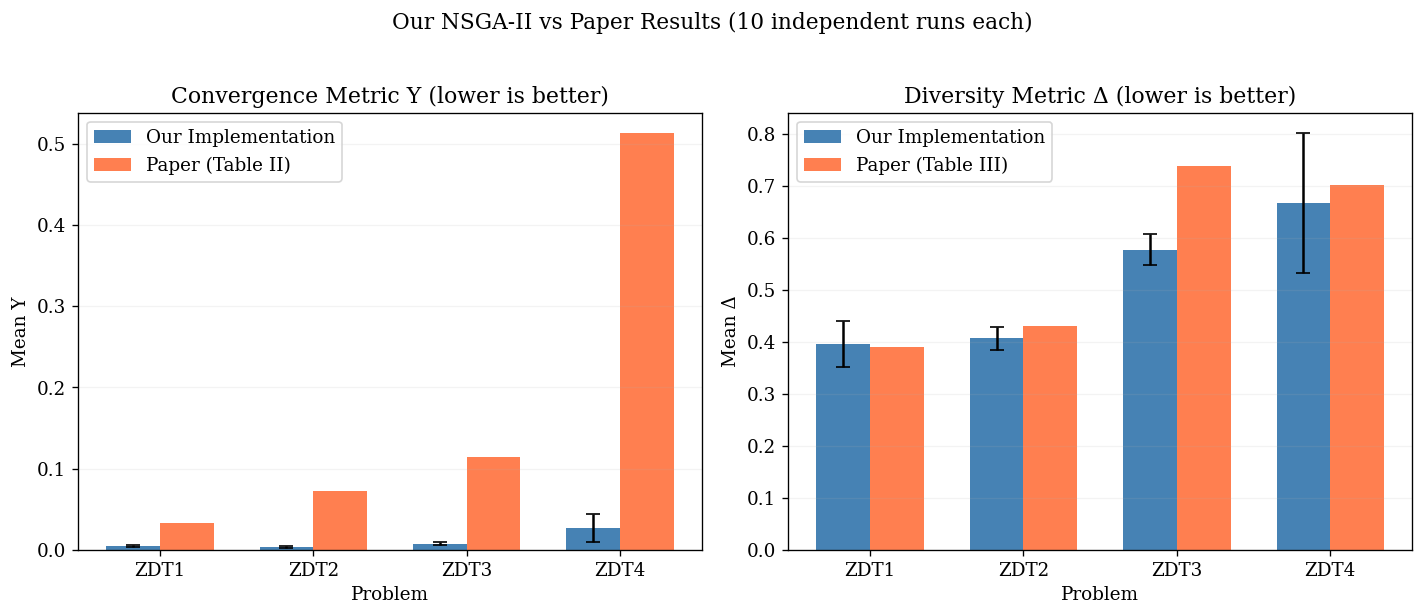

In [ ]:
problems = ["ZDT1", "ZDT2", "ZDT3", "ZDT4"]
x_pos = np.arange(len(problems))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ---- Convergence metric Υ ----
our_ups_means = [np.mean(trial_results[p][0]) for p in problems]
our_ups_stds  = [np.std(trial_results[p][0]) for p in problems]
paper_ups_means = [PAPER_VALUES[p][0] for p in problems]

ax1.bar(x_pos - width/2, our_ups_means, width, yerr=our_ups_stds,
        label="Our Implementation", color="steelblue", capsize=4)
ax1.bar(x_pos + width/2, paper_ups_means, width,
        label="Paper (Table II)", color="coral", capsize=4)
ax1.set_xlabel("Problem")
ax1.set_ylabel("Mean \u03a5")
ax1.set_title("Convergence Metric \u03a5 (lower is better)")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(problems)
ax1.legend()
ax1.grid(True, alpha=0.15, axis="y")

# ---- Diversity metric Δ ----
our_dlt_means = [np.mean(trial_results[p][1]) for p in problems]
our_dlt_stds  = [np.std(trial_results[p][1]) for p in problems]
paper_dlt_means = [PAPER_VALUES[p][2] for p in problems]

ax2.bar(x_pos - width/2, our_dlt_means, width, yerr=our_dlt_stds,
        label="Our Implementation", color="steelblue", capsize=4)
ax2.bar(x_pos + width/2, paper_dlt_means, width,
        label="Paper (Table III)", color="coral", capsize=4)
ax2.set_xlabel("Problem")
ax2.set_ylabel("Mean \u0394")
ax2.set_title("Diversity Metric \u0394 (lower is better)")
ax2.set_xticks(x_pos)
ax2.set_xticklabels(problems)
ax2.legend()
ax2.grid(True, alpha=0.15, axis="y")

plt.suptitle("Our NSGA-II vs Paper Results (10 independent runs each)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## ZDT6 (Nonuniform Pareto-Optimal Density)

The paper also tests on **ZDT6**.
- The density of Pareto-optimal solutions is **nonuniform along the front** — the exponential term $e^{-4x_1}$ causes solutions to cluster near $f_1 = 1$.

- This stresses the crowding-distance mechanism's ability to spread solutions uniformly.

**Definition** (n = 10, $x_i \in [0,1]$):

$$f_1(x) = 1 - e^{-4 x_1} \sin^6(6\pi x_1)$$

$$g(x) = 1 + 9 \left( \frac{\sum_{i=2}^{n} x_i}{n-1} \right)^{0.25}$$

$$f_2(x) = g(x)\left(1 - \left(\frac{f_1}{g}\right)^2 \right)$$

True Pareto front: $f_2 = 1 - f_1^2$ where $f_1 \in [0.2807753191, 1]$ (the minimum of $f_1$ is nonzero due to the exponential).

Running NSGA-II on ZDT6 ...
  Gen 50/250 — best f1: 0.280775
  Gen 100/250 — best f1: 0.280775
  Gen 150/250 — best f1: 0.280775
  Gen 200/250 — best f1: 0.280775
  Gen 250/250 — best f1: 0.280775


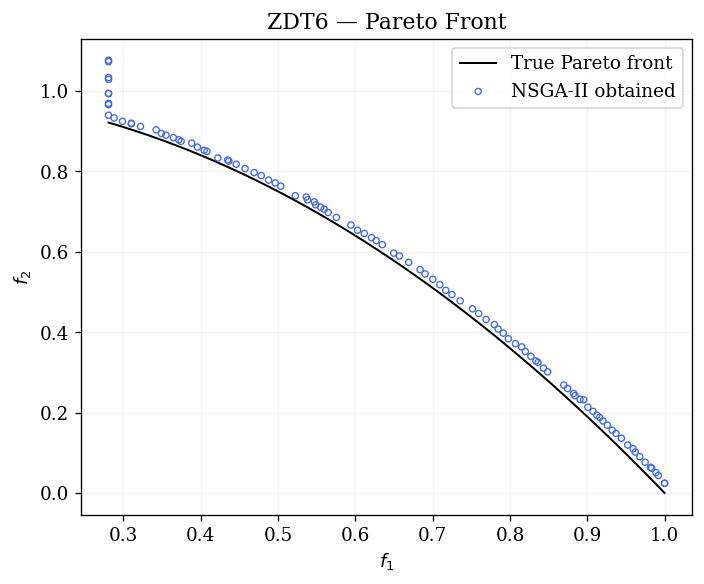


ZDT6 front size: 100
ZDT6 Υ = 0.019247   Δ = 0.452067


In [ ]:
# ---- ZDT6 definition ----
def zdt6(x):
    n = len(x)
    f1 = 1.0 - np.exp(-4.0 * x[0]) * (np.sin(6.0 * np.pi * x[0])) ** 6
    g  = 1.0 + 9.0 * (np.sum(x[1:]) / (n - 1)) ** 0.25
    f2 = g * (1.0 - (f1 / g) ** 2)
    return [f1, f2]

def zdt6_bounds(n=10):
    return [(0.0, 1.0)] * n

def zdt6_front(n_points=500):
    # Pareto front: f2 = 1 - f1^2 for f1 in [0.2807753191, 1]
    f1 = np.linspace(0.2807753191, 1.0, n_points)
    return f1, 1.0 - f1 ** 2

PROBLEMS["ZDT6"] = {"fn": zdt6, "bounds": zdt6_bounds, "front": zdt6_front, "n_vars": 10}

# ---- Run NSGA-II on ZDT6 ----
print("Running NSGA-II on ZDT6 ...")
cfg = PROBLEMS["ZDT6"]
bounds = cfg["bounds"](cfg["n_vars"])
pop_zdt6, hist_zdt6 = run_nsga2(
    problem_fn=cfg["fn"], N=N_POP, n_vars=cfg["n_vars"],
    bounds=bounds, n_generations=N_GEN,
    eta_c=ETA_C, eta_m=ETA_M, seed=SEED,
)
front1 = [ind for ind in pop_zdt6 if ind.rank == 1]
f1_zdt6 = [ind.objectives[0] for ind in front1]
f2_zdt6 = [ind.objectives[1] for ind in front1]

# ---- Plot ----
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
true_f1, true_f2 = zdt6_front(500)
ax.plot(true_f1, true_f2, "k-", linewidth=1.2, label="True Pareto front", zorder=1)
order = np.argsort(f1_zdt6)
ax.scatter(np.array(f1_zdt6)[order], np.array(f2_zdt6)[order],
           s=14, facecolors="none", edgecolors="royalblue",
           linewidths=0.8, zorder=2, label="NSGA-II obtained")
ax.set_xlabel(r"$f_1$"); ax.set_ylabel(r"$f_2$")
ax.set_title("ZDT6 — Pareto Front")
ax.legend(); ax.grid(True, alpha=0.15)
plt.tight_layout(); plt.show()

# ---- Metrics ----
ups = convergence_metric(f1_zdt6, f2_zdt6, true_f1, true_f2)
dlt = diversity_metric(f1_zdt6, f2_zdt6, true_f1, true_f2)
print(f"\nZDT6 front size: {len(front1)}")
print(f"ZDT6 \u03a5 = {ups:.6f}   \u0394 = {dlt:.6f}")